## Read output files

In [1]:
import awkward as ak
import numpy as np
import uproot
import os
import pandas as pd

In [3]:
BKG = {'QCD', 'GJets', 'ZJetsToQQ', 'WJetsToQQ', 'TTGJets'}
basedir = {
    '2016APV': {
        'data': '../condor/output/data/2016APV/SinglePhoton/',
        'ZJetsToQQ': '../condor/output/mc/2016APV/ZJetsToQQ/',
        'WJetsToQQ': '../condor/output/mc/2016APV/WJetsToQQ/',
        'TTGJets': '../condor/output/mc/2016APV/TTGJets/',
        'QCD': '../condor/output/mc/2016APV/QCD',
        'GJets': '../condor/output/mc/2016APV/GJets',
        'ZpToHGamma_M1000': '../condor/output/mc/2016APV/ZpToHGamma/ZpToHGamma_M1000/',
        'ZpToHGamma_M2000': '../condor/output/mc/2016APV/ZpToHGamma/ZpToHGamma_M2000/',
        'ZpToHGamma_M3000': '../condor/output/mc/2016APV/ZpToHGamma/ZpToHGamma_M3000/',
    },
    '2016': {
        'data': '../condor/output/data/2016/SinglePhoton/',
        'ZJetsToQQ': '../condor/output/mc/2016/ZJetsToQQ/',
        'WJetsToQQ': '../condor/output/mc/2016/WJetsToQQ/',
        'TTGJets': '../condor/output/mc/2016/TTGJets/',
        'QCD': '../condor/output/mc/2016/QCD',
        'GJets': '../condor/output/mc/2016/GJets',
        'ZpToHGamma_M1000': '../condor/output/mc/2016/ZpToHGamma/ZpToHGamma_M1000/',
        'ZpToHGamma_M2000': '../condor/output/mc/2016/ZpToHGamma/ZpToHGamma_M2000/',
        'ZpToHGamma_M3000': '../condor/output/mc/2016/ZpToHGamma/ZpToHGamma_M3000/',
    },
    '2017': {
        'data': '../condor/output/data/2017/SinglePhoton/',
        'ZJetsToQQ': '../condor/output/mc/2017/ZJetsToQQ/',
        'WJetsToQQ': '../condor/output/mc/2017/WJetsToQQ/',
        'TTGJets': '../condor/output/mc/2017/TTGJets/',
        'QCD': '../condor/output/mc/2017/QCD',
        'GJets': '../condor/output/mc/2017/GJets',
        'ZpToHGamma_M1000': '../condor/output/mc/2017/ZpToHGamma/ZpToHGamma_M1000/',
        'ZpToHGamma_M2000': '../condor/output/mc/2017/ZpToHGamma/ZpToHGamma_M2000/',
        'ZpToHGamma_M3000': '../condor/output/mc/2017/ZpToHGamma/ZpToHGamma_M3000/',
    },
    '2018': {
        'data': '../condor/output/data/2018/EGamma/',
        'ZJetsToQQ': '../condor/output/mc/2018/ZJetsToQQ/',
        'WJetsToQQ': '../condor/output/mc/2018/WJetsToQQ/',
        'TTGJets': '../condor/output/mc/2018/TTGJets/',
        'QCD': '../condor/output/mc/2018/QCD',
        'GJets': '../condor/output/mc/2018/GJets',
        #'ZpToHGamma_M1000': '../condor/output/mc/2018/ZpToHGamma/ZpToHGamma_M1000/',
        #'ZpToHGamma_M2000': '../condor/output/mc/2018/ZpToHGamma/ZpToHGamma_M2000/',
        #'ZpToHGamma_M3000': '../condor/output/mc/2018/ZpToHGamma/ZpToHGamma_M3000/',
        'ZpToHGamma': '../condor/output/mc/2018/ZpToHGamma/',
    },
}

filepath={year: {c: [] for c in basedir[year]} for year in basedir}
for year in basedir:
    for c in basedir[year]:
        for (current_path, dirs, files) in os.walk(basedir[year][c]):
            for f in files:
                if f.endswith('.parq'):
                    filepath[year][c].append(os.path.join(current_path, f))

filepath

{'2016APV': {'data': ['../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-9.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-2.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-10.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-18.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-3.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-5.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-6.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-14.parq',
   '../condor/output/data/2016APV/SinglePhoton/SinglePhoton_Run2016D/data_2016APV_SinglePhoton-7.parq',
   '../condor/output/data/2016APV/SinglePh

In [4]:
events = {year: {k: [] for k in filepath[year]} for year in filepath}
for year in filepath:
    for k, v in filepath[year].items():
        for f in v:
            if os.path.getsize(f) == 0:
                print('Zero size:', f)
                continue
            if len(pd.read_parquet(f))==0:
                continue
            array = ak.from_parquet(f)
            if len(array)>0:
                events[year][k].append(array)
        if len(events[year][k]) > 0:
            events[year][k] = ak.concatenate(events[year][k], axis=0)

del events['2016APV']['ZpToHGamma_M1000'], events['2016APV']['ZpToHGamma_M2000'], events['2016APV']['ZpToHGamma_M3000']
del events['2016']['ZpToHGamma_M1000'], events['2016']['ZpToHGamma_M2000'], events['2016']['ZpToHGamma_M3000']
events

{'2016APV': {'data': <Array [{AK8jet_msoftdrop: 49.8, ... ] type='200869 * {"AK8jet_msoftdrop": ?floa...'>,
  'ZJetsToQQ': <Array [{AK8jet_eta: 0.88, ... ] type='1123 * {"AK8jet_eta": ?float32, "AK8jet_p...'>,
  'WJetsToQQ': <Array [{AK8jet_mass: 92.4, ... ] type='5286 * {"AK8jet_mass": ?float32, "AK8jet...'>,
  'TTGJets': <Array [{AK8jet_eta: 0.274, ... ] type='15047 * {"AK8jet_eta": ?float32, "AK8jet...'>,
  'QCD': <Array [{AK8jet_pt: 252, ... ] type='5464 * {"AK8jet_pt": ?float32, "AK8jet_phi"...'>,
  'GJets': <Array [{AK8jet_pt: 390, ... ] type='165212 * {"AK8jet_pt": ?float32, "AK8jet_ms...'>},
 '2016': {'data': <Array [{AK8jet_eta: 0.15, ... ] type='180098 * {"AK8jet_eta": ?float32, "AK8jet...'>,
  'ZJetsToQQ': <Array [{AK8jet_phi: 2.59, ... ] type='1187 * {"AK8jet_phi": ?float32, "AK8jet_p...'>,
  'WJetsToQQ': <Array [{AK8jet_phi: 0.593, ... ] type='4697 * {"AK8jet_phi": ?float32, "AK8jet_...'>,
  'TTGJets': <Array [{AK8jet_pt: 635, ... ] type='14312 * {"AK8jet_pt": ?float32, "A

In [5]:
for y in events:
    for i in events[y]:
        if i=='data' or len(events[y][i])==0:
            continue
        print(y, i, set(events[y][i].event_weight), sep='\t')

2016APV	ZJetsToQQ	{0.08116985112428665, 0.07646702975034714, 0.2891616276185841}
2016APV	WJetsToQQ	{0.15073029696941376, 1.047285890917163, 6.219115333253672, 0.08478778600692749}
2016APV	TTGJets	{-0.1339229941368103, 0.1339229941368103}
2016APV	QCD	{0.2438502162694931, 0.5557921896294605, 4.465450215491642, 37.295262295070536, 7.83329274409996, 411.48827801959766}
2016APV	GJets	{0.3567803430487077, 1.1599619573961562, 2.2495992133445673, 19.931507189286965}
2016	ZJetsToQQ	{0.07702954858541489, 0.27650582956127556, 2.3349551921970697, 0.05592605099081993}
2016	WJetsToQQ	{0.0836886614561081, 1.0431145282395986, 0.14637282490730286}
2016	TTGJets	{0.12318432331085205, -0.12318432331085205}
2016	QCD	{0.18513205647468567, 0.5582986622863015, 35.647636123417875, 324.61550256952626, 4.204431844027235, 7.755525475114171}
2016	GJets	{0.3516505770269691, 0.9681981214317726, 2.0136193552631614, 15.091157350946943}
2017	ZJetsToQQ	{0.3182417261125692, 0.08981817960739136, 2.7515034937372427, 0.0644

## Decomposite signal

In [6]:
def decomposite(signal: ak.Array):
    HWW_decay_mode = ak.fill_none(signal['gen_HWW_decay_mode'], 0)

    for tag in set(signal.fields):
        if tag.startswith('gen_Zp') and tag!='gen_ZpToHGamma':
            signal[tag.split('_')[1]] = signal[signal[tag]]
    
    signal['HWW_4q'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode >= 32)
    ]
    
    signal['HWW_qqlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode > 16) &
        (HWW_decay_mode < 32)
    ]
    
    signal['HWW_lvlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode <= 16)
    ]
    
    return signal

DECOMPOSITE = False
if DECOMPOSITE:
    for y in events:
        for c in events[y]:
            if c.startswith('ZpToHGamma'):
                events[y].update({c: decomposite(events[y][c])})
events

{'2016APV': {'data': <Array [{AK8jet_msoftdrop: 49.8, ... ] type='200869 * {"AK8jet_msoftdrop": ?floa...'>,
  'ZJetsToQQ': <Array [{AK8jet_eta: 0.88, ... ] type='1123 * {"AK8jet_eta": ?float32, "AK8jet_p...'>,
  'WJetsToQQ': <Array [{AK8jet_mass: 92.4, ... ] type='5286 * {"AK8jet_mass": ?float32, "AK8jet...'>,
  'TTGJets': <Array [{AK8jet_eta: 0.274, ... ] type='15047 * {"AK8jet_eta": ?float32, "AK8jet...'>,
  'QCD': <Array [{AK8jet_pt: 252, ... ] type='5464 * {"AK8jet_pt": ?float32, "AK8jet_phi"...'>,
  'GJets': <Array [{AK8jet_pt: 390, ... ] type='165212 * {"AK8jet_pt": ?float32, "AK8jet_ms...'>},
 '2016': {'data': <Array [{AK8jet_eta: 0.15, ... ] type='180098 * {"AK8jet_eta": ?float32, "AK8jet...'>,
  'ZJetsToQQ': <Array [{AK8jet_phi: 2.59, ... ] type='1187 * {"AK8jet_phi": ?float32, "AK8jet_p...'>,
  'WJetsToQQ': <Array [{AK8jet_phi: 0.593, ... ] type='4697 * {"AK8jet_phi": ?float32, "AK8jet_...'>,
  'TTGJets': <Array [{AK8jet_pt: 635, ... ] type='14312 * {"AK8jet_pt": ?float32, "A

## Start plotting

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

def flow(hist: bh.Histogram, overflow: bool=True, underflow: bool=False):
    h, var = hist.view(flow=(overflow | underflow)).value, hist.view(flow=(overflow | underflow)).variance
    if overflow: ## h, var also include underflow bins but in plots usually no underflow data
        ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
        h[-2]+=h[-1]; var[-2]+=var[-1]
    if underflow:
        h[1]+=h[0]; var[1]+=var[0]
    if overflow or underflow:
        h = h[1:-1]; var = var[1:-1]
    return h, var

weight={y: {c: events[y][c].event_weight for c in events[y] if c!='data'} for y in events}

In [12]:
def data_compare_plot(arrays, plot_name: str, x_name: str, cuts=None, bins=40, x_min=0, x_max=3000, density=True, overflow=True, underflow=False):
    bin_width = (x_max-x_min)/bins
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=True, ax=ax, fontsize=18)
    
    ## analyze

        
    ## plot
    mpl.rcParams['axes.prop_cycle'] = cycler(color=['red', 'blue', 'green', 'darkorange', 'cyan', 'HotPink', 'darkviolet', 'SlateGray', 'black', 'LightSkyBlue'])
    for (k, v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        hist.fill(v)
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        hep.histplot(h, bins=hist.axes[0].edges, xerr=bin_width/2, yerr=np.sqrt(var), label=k, histtype='step', density=density, stack=False, ax=ax, linewidth=2)
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 

    ## axises
    ax.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax.set_xlim(x_min, x_max)
    if 'eta' in plot_name:
        ax.set_ylim(1e-2, ax.get_ylim()[1]*5)
    else:
        ax.set_ylim(1e-8, ax.get_ylim()[1]*5)
    ax.set_yscale('log')
    #ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=2, frameon=False, fontsize=18)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig(f"./plots/data_compare_{plot_name}{suffix}.pdf", bbox_inches='tight')
    plt.show()

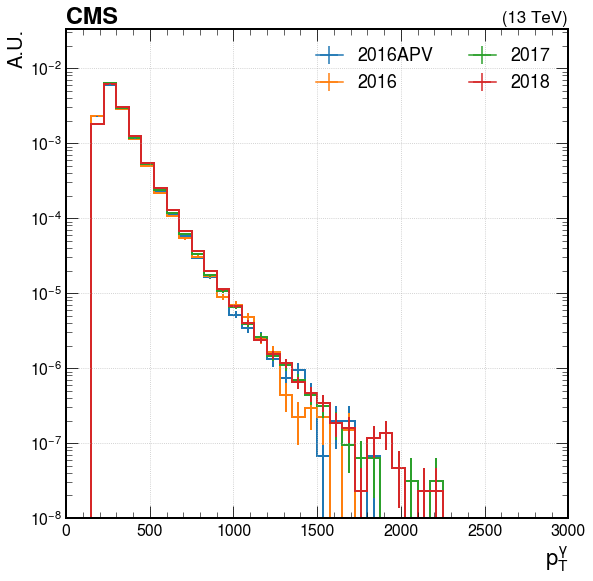

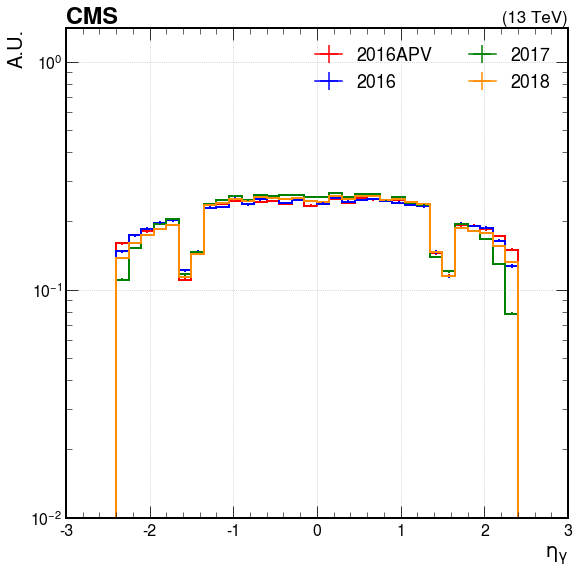

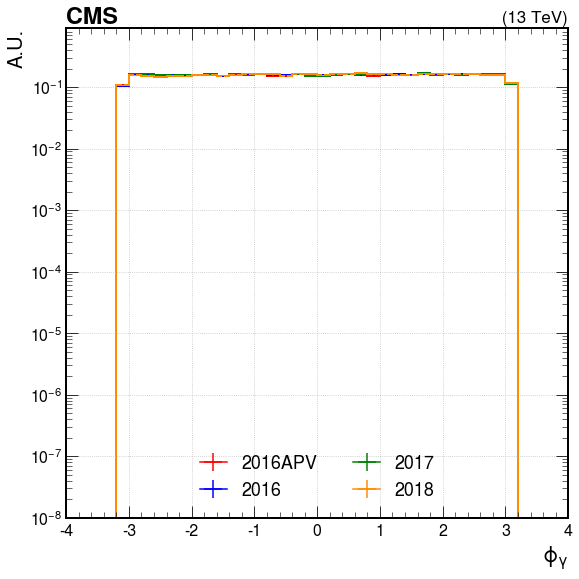

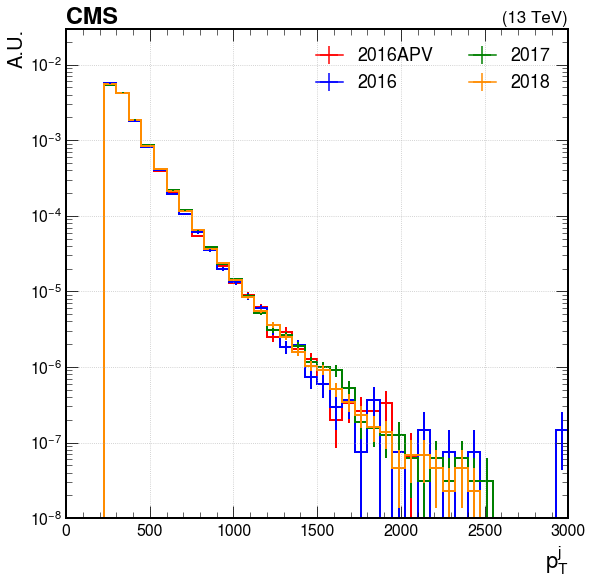

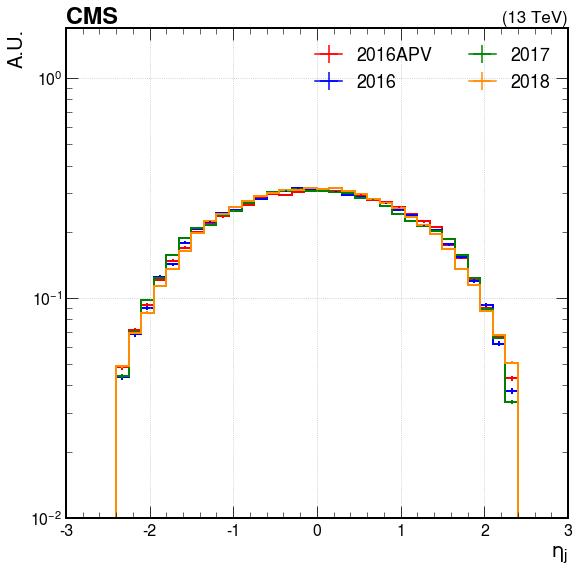

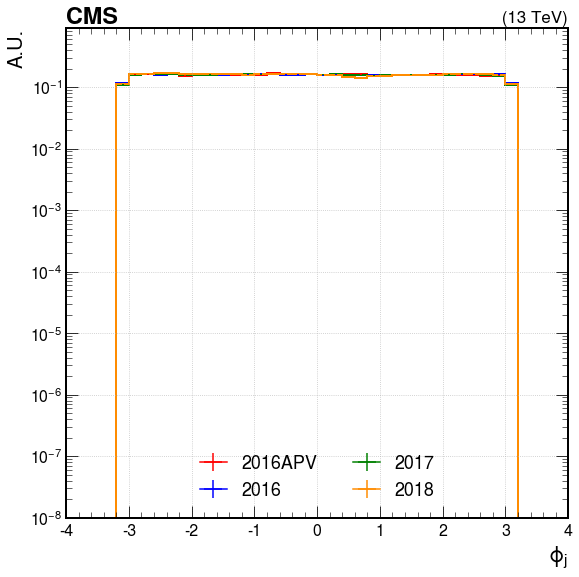

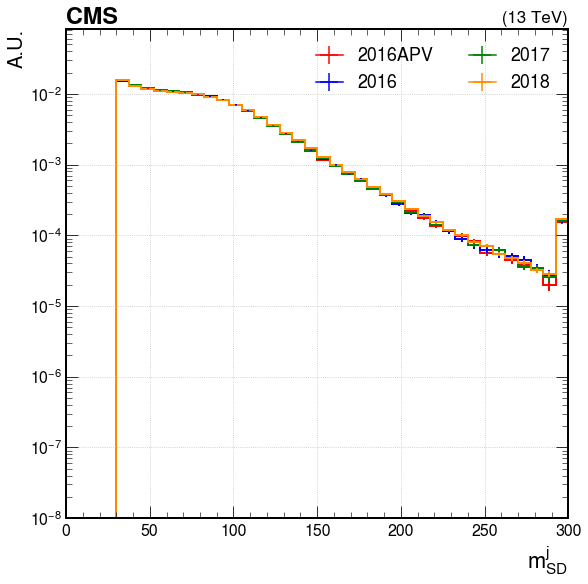

In [9]:
arrays={k: events[k]['data'].photon_pt for k in events}
data_compare_plot(arrays, 'photon_pt', x_name=r'$p_T^{\gamma}$')

arrays={k: events[k]['data'].photon_eta for k in events}
data_compare_plot(arrays, 'photon_eta', x_name=r'$\eta_{\gamma}$', x_min=-3, x_max=3)

arrays={k: events[k]['data'].photon_phi for k in events}
data_compare_plot(arrays, 'photon_phi', x_name=r'$\phi_\gamma$', x_min=-4, x_max=4)

arrays={k: events[k]['data'].AK8jet_pt for k in events}
data_compare_plot(arrays, 'AK8jet_pt', x_name=r'$p_T^j$')

arrays={k: events[k]['data'].AK8jet_eta for k in events}
data_compare_plot(arrays, 'AK8jet_eta', x_name=r'$\eta_j$', x_min=-3, x_max=3)

arrays={k: events[k]['data'].AK8jet_phi for k in events}
data_compare_plot(arrays, 'AK8jet_phi', x_name=r'$\phi_j$', x_min=-4, x_max=4)

arrays={k: events[k]['data'].AK8jet_msoftdrop for k in events}
data_compare_plot(arrays, 'AK8jet_msoftdrop', x_name=r'$m_{SD}^j$', x_min=0, x_max=300)

In [14]:
def data_mc_compare_plot(arrays, weight, plot_name: str, x_name: str, cuts=None, year='2018', bins=40, x_min=0, x_max=2000, density=False, overflow=True, underflow=False):
    LUMI = {"2016APV": 19.52, "2016": 16.81, "2017": 41.48, "2018": 59.83,}
    bin_width = (x_max-x_min)/bins
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
        
    ## canvas initializing
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 10))
    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[5, 1, 1], hspace=0.1)
    ax = f.add_subplot(gs[0])
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=True, year=year.replace('APV', ''), ax=ax, lumi=LUMI[year], fontsize=18)
    ## Ratio panel
    ax1 = f.add_subplot(gs[1])
    ax2 = f.add_subplot(gs[2])
    ax1.grid()
    ax2.grid()
    
    ## analyze
    stacked = {'h': {}, 'var': {}}
    individual = {'h': {}, 'var': {}}
    
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if 'delta_phi' in plot_name:
            values = np.min([v, 2*np.pi-v], axis=0)
        values = ak.fill_none(v, -999)
        
        if k!='data':
            hist.fill(values, weight=weight[k])
        else:
            hist.fill(values)
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        if k in BKG: 
            stacked['h'][k] = h
            stacked['var'][k] = var
        else:
            individual['h'][k] = h
            individual['var'][k] = var

    ## plot
    mpl.rcParams['axes.prop_cycle'] = cycler(color=['darkorange', 'cyan', 'HotPink', 'darkviolet', 'SlateGray', 'black', 'LightSkyBlue'])
    SIG_COLOR={'ZpToHGamma_M1000': 'red', 'ZpToHGamma_M2000': 'blue', 'ZpToHGamma_M3000': 'green'}
    ax1.plot([x_min,x_max], [1,1], color='black', linestyle='dashed')
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 
    hep.histplot(list(stacked['h'].values()), bins=hist.axes[0].edges, label=list(stacked['h'].keys()), histtype='fill', density=density, stack=True, linewidth=2, ax=ax)
    bkg_h = np.sum(list(stacked['h'].values()), axis=0)
    bkg_var = np.sum(list(stacked['var'].values()), axis=0)
    for (k,v) in individual['h'].items():
        if k=='data':
            hep.histplot(v, bins=hist.axes[0].edges, yerr=np.sqrt(individual['var'][k]), label=k, color='black', histtype='errorbar', density=density, stack=False, ax=ax)
            hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')
        else:  # signal
            hep.histplot(v, bins=hist.axes[0].edges, yerr=np.sqrt(individual['var'][k]), label=k, histtype='step', density=density, stack=False, linewidth=2, ax=ax, color=SIG_COLOR[k])
            y = v / np.sqrt(bkg_h + 1)
            hep.histplot(y, bins=hist.axes[0].edges, label=k, histtype='step', density=density, stack=False, ax=ax2, color=SIG_COLOR[k])

    ## axises
    ax.set_xlim(x_min, x_max)
    #ax.set_xticklabels([])
    ax.set_ylim(0.01, ax.get_ylim()[1]*1e2)
    ax.set_yscale('log')
    #ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='x', which='major', labelsize=0)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)
    
    ax1.set_xlim(x_min, x_max)
    ax1.set_xticklabels([])
    ax1.set_ylim(0, 2)
    ax1.set_ylabel(r'$\frac{data}{bkg_mc}$', ha='center', fontsize=24)
    #ax1.ticklabel_format(useOffset=False, style='plain')
    ax1.tick_params(axis='both', which='major', labelsize=16)
    
    #ax2.set_yscale('log')
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax2.set_ylabel(r'$S/\sqrt{B+1}$', ha='center', fontsize=16)
    ax2.ticklabel_format(useOffset=False, style='plain')
    ax2.tick_params(axis='both', which='major', labelsize=16)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=3, frameon=False, fontsize=15)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig(f"./plots/{year}_{plot_name}{suffix}.pdf", bbox_inches='tight')
    plt.show()

In [15]:
print(events.keys())
print(events['2018']['data'].fields)

dict_keys(['2016APV', '2016', '2017', '2018'])
['AK8jet_msoftdrop', 'AK8jet_mass', 'AK8jet_phi', 'AK8jet_eta', 'AK8jet_pt', 'photon_phi', 'photon_eta', 'photon_pt', 'photon_mass', 'event_MET_pt', 'event_genWeight', 'photon-jet_phi', 'photon-jet_eta', 'photon-jet_pt', 'photon-jet_mass', 'photon-jet_deltaR']


In [22]:
import os
import json
with open(os.path.join('../src/json/', 'filters.json'), 'r', encoding ='utf-8') as f:
    x = json.load(f)

In [19]:
events['2018']['ZpToHGamma'].fields

['AK8jet_msoftdrop',
 'AK8jet_phi',
 'AK8jet_eta',
 'AK8jet_mass',
 'AK8jet_pt',
 'photon_phi',
 'photon_eta',
 'photon_mass',
 'photon_pt',
 'event_genWeight',
 'event_MET_pt',
 'photon-jet_phi',
 'photon-jet_eta',
 'photon-jet_mass',
 'photon-jet_pt',
 'photon-jet_deltaR',
 'gen_ZpToHGamma',
 'gen_ZpToH(WW)Gamma',
 'gen_ZpToH(bb)Gamma',
 'gen_ZpToH(ZZ)Gamma',
 'gen_ZpToH(tautau)Gamma',
 'gen_ZpToH(gammagamma)Gamma',
 'gen_HWW_decay_mode',
 'event_weight']

In [16]:
arrays = {'2018': events['2018']['ZpToHGamma']}

KeyError: 2018

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: divide by zero encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')
/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


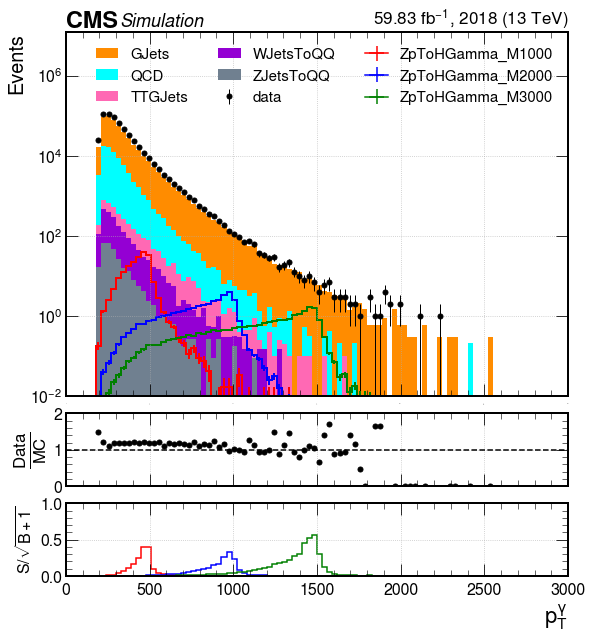

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


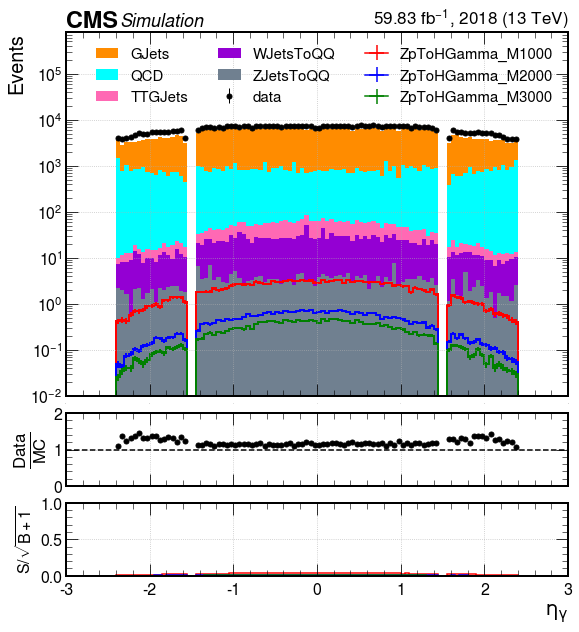

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


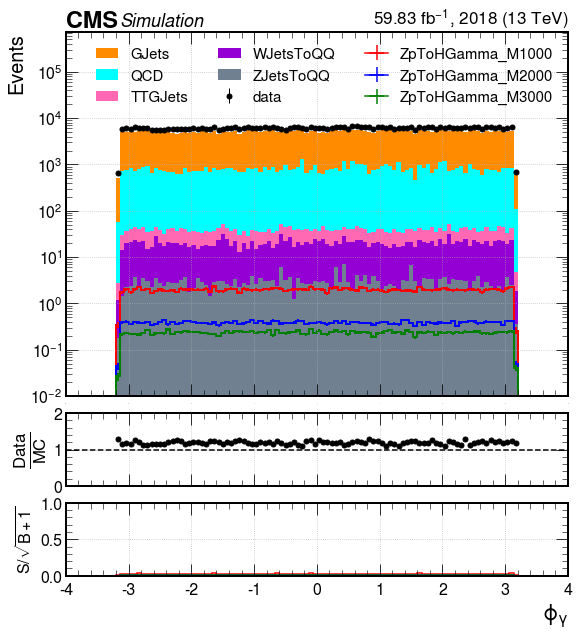

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


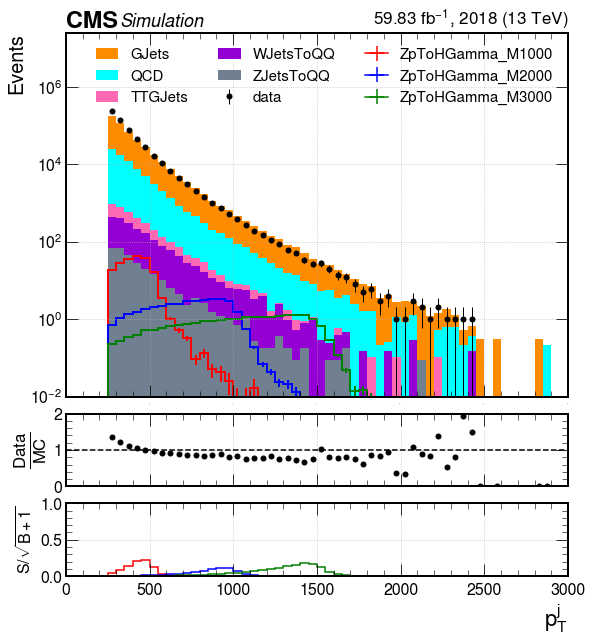

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: divide by zero encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')
/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


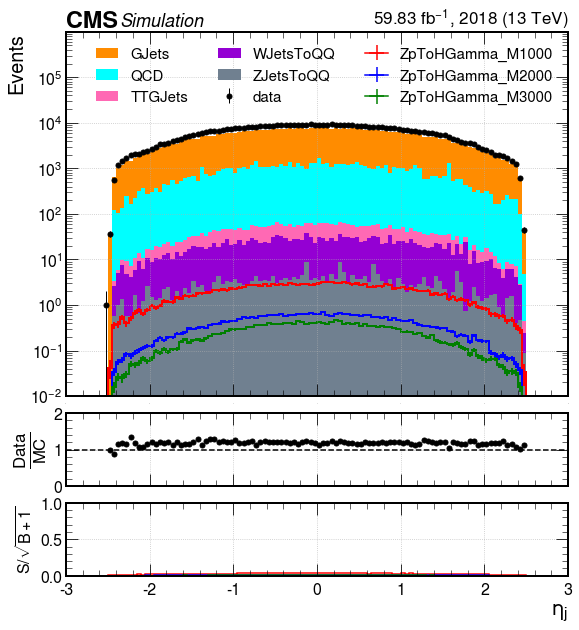

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


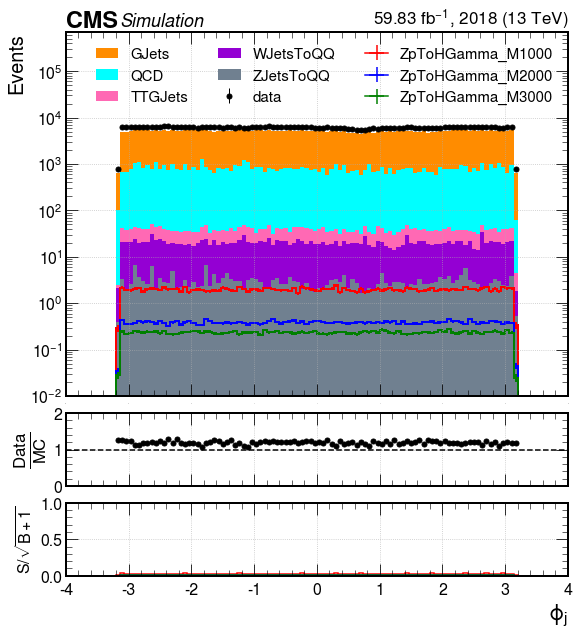

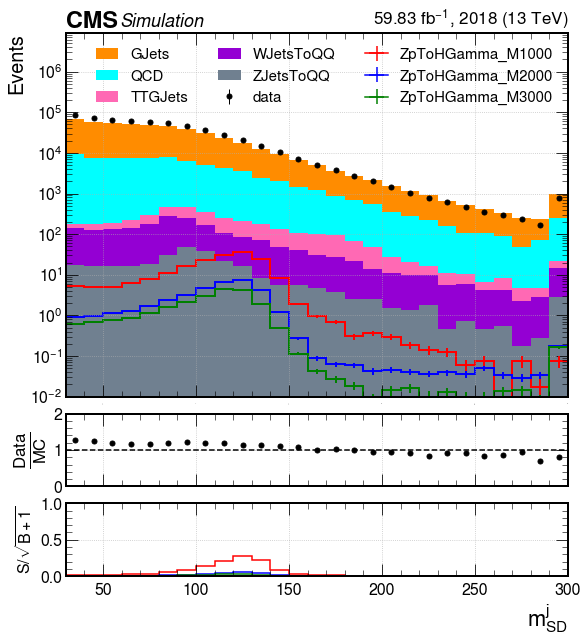

In [57]:
for y in events:
    if y!='2018':
        continue
    arrays={k: events[y][k].photon_pt for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon_pt', x_name=r'$p_T^{\gamma}$', x_max=3000, x_min=0, bins=100, weight=weight[y], year=y)
    arrays={k: events[y][k].photon_eta for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon_eta', x_name=r'$\eta_{\gamma}$', x_max=3, x_min=-3, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].photon_phi for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon_phi', x_name=r'$\phi_{\gamma}$', x_max=4, x_min=-4, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_pt for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_pt', x_name=r'$p_T^{j}$', x_max=3000, x_min=0, bins=60, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_eta for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_eta', x_name=r'$\eta_j$', x_max=3, x_min=-3, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_phi for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_phi', x_name=r'$\phi_j$', x_max=4, x_min=-4, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_msoftdrop for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_msoftdrop', x_name=r'$m_{SD}^{j}$', x_max=300, x_min=30, bins=27, weight=weight[y], year=y)

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


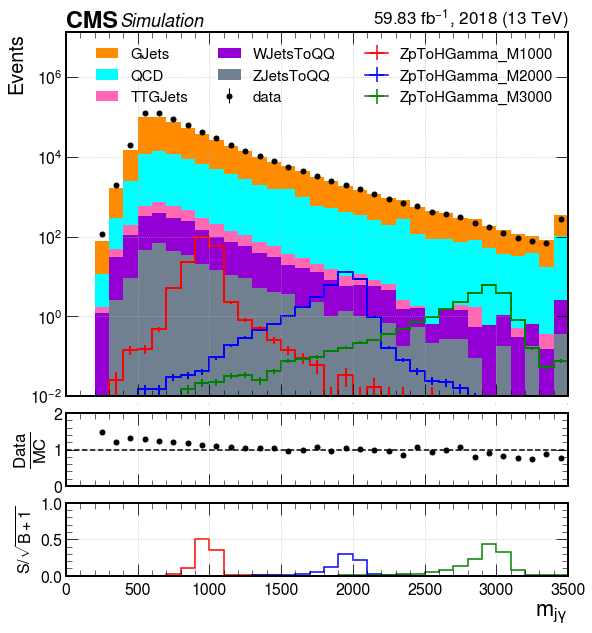

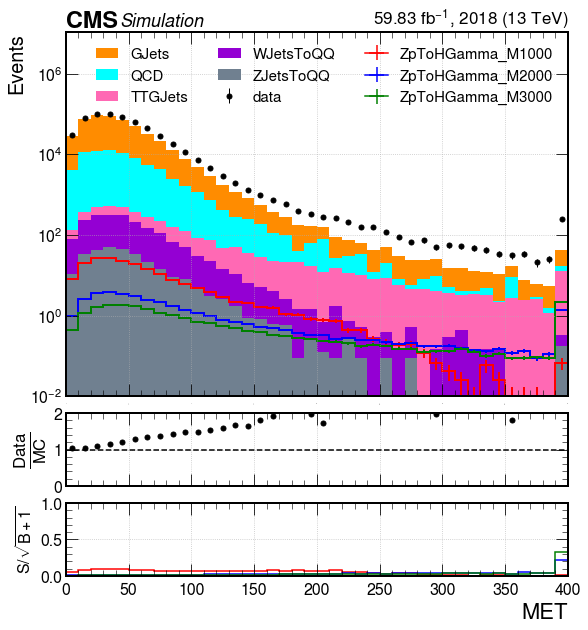

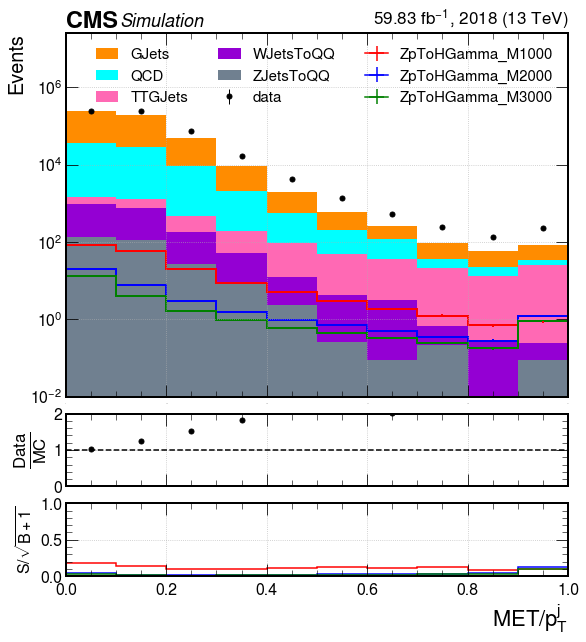

In [48]:
for y in events:
    if y!='2018':
        continue
    arrays={k: events[y][k]['photon-jet_mass'] for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon-jet_mass', x_name=r'$m_{j\gamma}$', x_max=3500, bins=35, weight=weight[y], year=y)
    arrays={k: events[y][k]['event_MET_pt'] for k in events[y]}
    data_mc_compare_plot(arrays, x_name='MET', plot_name='event_MET_pt', x_max=400, bins=40, weight=weight[y], year=y)
    arrays={k: events[y][k].event_MET_pt/events[y][k].AK8jet_pt for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='MET_over_AK8jet_pt', x_name=r'$MET/p_T^{j}$', x_max=1, x_min=0, bins=10, weight=weight[y], year=y)

/tmp/dfu/ipykernel_6425/1427863281.py:54: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


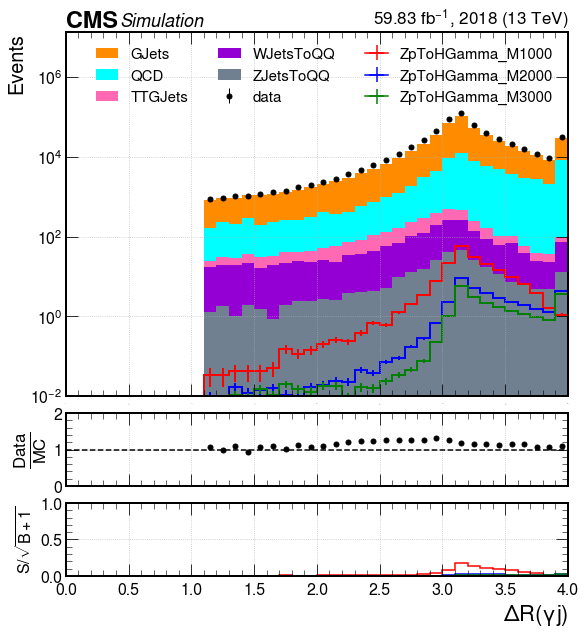

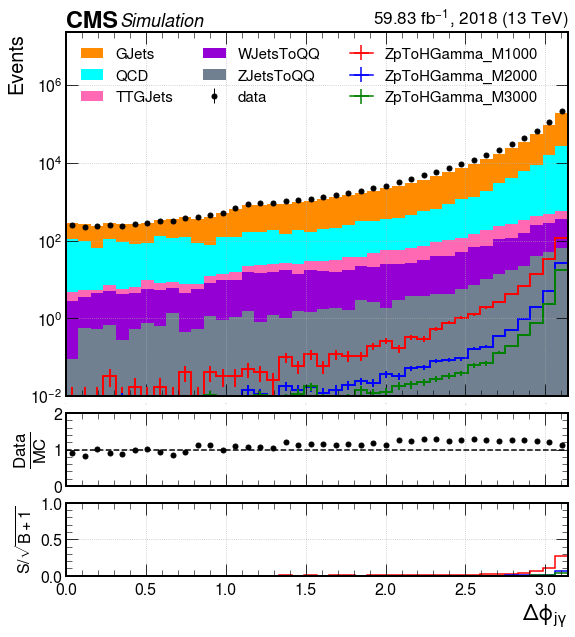

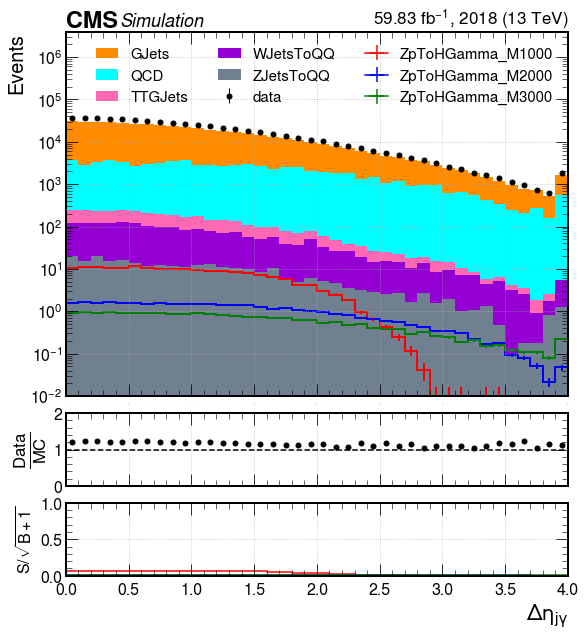

In [49]:
for y in events:
    if y!='2018':
        continue
    arrays={k: events[y][k]['photon-jet_deltaR'] for k in events[y]}
    data_mc_compare_plot(arrays, x_name=r'$\Delta R(\gamma j)$', plot_name='photon-jet_deltaR', x_max=4, bins=40, weight=weight[y], year=y)
    arrays={k: np.min([abs(events[y][k].photon_phi - events[y][k].AK8jet_phi), 2*np.pi - abs(events[y][k].photon_phi - events[y][k].AK8jet_phi)], axis=0) for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon-jet_delta_phi', x_name=r'$\Delta\phi_{j\gamma}$', x_max=np.pi, x_min=0, bins=40, weight=weight[y], year=y)
    arrays={k: abs(events[y][k].photon_eta - events[y][k].AK8jet_eta) for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon-jet_delta_eta', x_name=r'$\Delta\eta_{j\gamma}$', x_max=4, x_min=0, bins=40, weight=weight[y], year=y)